In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: Generating random numbers in a range

Using numpy.random (or whatever you like), generate:

*	An integer random number in a range [0,5] (using random.integers)
*	100 float random numbers in a range [0,5] (using random.uniform)
*	A 3x3 matrix of floats random number in a range [0,2]

Try using seed and without seed to see the difference.

In [3]:
# Task 1: Generate a random integer between 0 and 5
print(f'Task 1: {random.randint(0, 5)}')

# Task 2: Generate a list of 100 random floats between 0 and 5
print(f'Task 2: {[random.uniform(0, 5) for _ in range(100)]}')

# Task 3: Generate a 3x3 matrix of random floats between 0 and 2
print(f'Task 3: {[[random.uniform(0, 2) for _ in range(3)] for _ in range(3)]}')

# Experiment with fixed seed
print('\nExperiment with fixed seed values:')

random.seed(42)
for i in range(5):
    print(f'Seed 42, i={i}: {random.random()}')

'''Instead of using current time, we use a fixed seed so results are the same every time we run the code'''

Task 1: 4
Task 2: [1.2620235883249205, 4.261516176904664, 2.832992504853781, 3.160952775474919, 1.2265956454955989, 3.307470323184666, 4.675220277087744, 4.640862916115524, 4.050831337859955, 3.861959840750303, 4.501976548810919, 1.7647324617601705, 3.657394216947437, 3.0450956499836677, 2.0311142888267257, 3.990385750845311, 2.295111840607778, 0.01281071304615522, 2.581105042103686, 2.397278050415623, 0.8308550544527443, 0.20951165735676125, 4.333473897143506, 2.466736600852564, 0.3009293702767085, 1.7624155743413201, 3.1736738555366846, 2.3009509070388283, 2.450432666053671, 4.9220632055214555, 1.888049038257114, 2.522728616401469, 2.3033946813982253, 0.6749256625719496, 2.768425658512056, 0.8022028846503704, 4.538293133694369, 0.8165891874336545, 4.317665458743398, 0.5118655494778013, 0.03245391287959698, 0.8148772123735715, 0.5953184404470258, 0.8799347197643892, 4.221949575669181, 4.299111660000748, 3.8737692480544696, 0.5380491767284273, 0.8889499490889036, 3.2227623202069116, 0.

'Instead of using current time, we use a fixed seed so results are the same every time we run the code'

# Exercise 2: Estimating $\pi$ value using the Monte Carlo method
Hint:
+	The area of a quarter unit circle is $\pi/4$
+	The area of a unit square is 1
$\Rightarrow \pi = 4*\dfrac{S_{\text{quarter circle}}}{S_{\text{square}}} \approx 4*\dfrac{\text{points in circle}}{\text{total points in square}}$

Step:
+	Generate a point (x,y) using 2 random numbers in a range [0,1]
+	Check if the point is inside the circle using the condition $x^2+y^2 <= 1 $
+	Repeat this procedure for many points and compute the ratio.
+	Verify the result by comparing |result - $\pi$|


In [4]:
def estimate_pi(points=1_000_000) -> float:
    points_in = 0

    # Generate random points in the unit square
    for _ in range(points):
        x = random.uniform(0, 1)
        y = random.uniform(0, 1)
        # Check if the point is inside the 1/4 circle
        if x**2 + y**2 <= 1:
            points_in += 1

    # PI can be estimated as 4 * (points inside the quarter circle / total points)
    return 4 * points_in / points


pi = estimate_pi()
print(f'PI: {pi:.3f}, Diff: {abs((math.pi - pi)):.3f}')

PI: 3.141, Diff: 0.000


# Exercise 3: Monte Carlo Integration

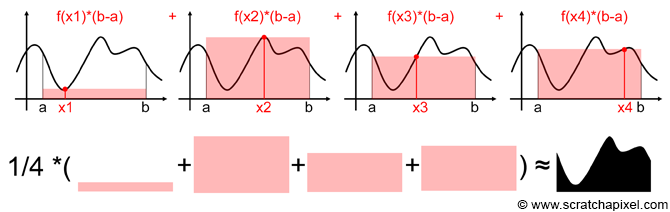

Integration:
$$I = \int_{a}^{b} y(x) dx$$
Monte Carlo Uniform distribution to estimate the integral:
$$\bar{I} = \dfrac{1}{N} \sum_{i=0}^{N-1} I(x_i)= \dfrac{1}{N} \sum_{i=0}^{N-1}(b-a) y(x_i).$$
where $I(x_i) = (b-a)y(x_i)$.

**Standard deviation** of I:
$$ \sigma_{I} =  \sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2}$$
**Standard error** of the estimate:
$$ \sigma_{\bar{I}} =  \dfrac{\sigma_I}{\sqrt{N}}$$
 <!-- $$ \Rightarrow \sigma_{\bar{I}} =  \dfrac{1}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2} =  \dfrac{(b-a)}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (y(x_i) - \overline{y})^2}$$ -->

+	Define a function named **MC_1dim(lower_bound,upper_bound,func,n_points)** to compute the integral of an arbitrary one-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and  the standard error  $\sigma_{\bar{I}}$ , i.e $<I> = \bar{I} \pm \sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi} sin(x) dx$ 

+	Verify the result by calculating the absolute error: $|\bar{I} - 2|$
+	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases?
+	Compare the convergence of the Monte Carlo method and the trapezoid (use np.trapezoid()) method by plotting the absolute error of both approaches using log-log scale. Which method converges faster for this one-dimensional integral? 
+	How do these method errors scale as O($1/N^{\alpha}$). Compute the slope to find the $\alpha$ value for each method by choosing any 2 pairs $(x_1,y_1), (x_2,y_2)$ from the log-log plot:

	$\alpha = -\dfrac{\log(y_2)-\log(y_1)}{\log(x_2)-\log(x_1)}$

Hint: The expected values are $\alpha_{MC} = 0.5$ and $\alpha_{trapezoid} = 2$.

In [41]:
def func(x):
    return math.sin(x)

def MC_1dim(lower, upper, func, points):
    if points <= 1:
        raise ValueError("Number of points must be greater than 1.")

    count = 0
    mean_f = 0.0
    M2 = 0.0
    
    for _ in range(points):
        x = random.uniform(lower, upper)
        val = func(x)

        # Update mean using Welford's algorithm 
        count += 1
        delta_1 = val - mean_f
        mean_f += delta_1 / count
        delta_2 = val - mean_f
        M2 += delta_1 * delta_2
    
    # Integral: (b - a) * average value of the function
    integral_f = (upper - lower) * mean_f

    # Variance
    variance_f = M2 / (points - 1)

    # Standard deviation
    std_dev_f = math.sqrt(variance_f)

    # Standard error
    std_error_f = (upper - lower) * std_dev_f / math.sqrt(points)

    return integral_f, std_error_f


integral, std_err = MC_1dim(0, math.pi, func, 1_000_000)

print(f'Estimated integral: {integral:.6f}')
print(f'Standard Error: {std_err:.6f}')
print(f'Absolute error: {abs(integral - 2):.6f}')

Estimated integral: 2.000107
Standard Error: 0.000967
Absolute error: 0.000107


In [ ]:
# Function to calculate the slope (alpha) of the log-log plot
def calculate_alpha(x_vals, y_vals):
    x1, x2 = x_vals[0], x_vals[-1]
    y1, y2 = y_vals[0], y_vals[-1]

    alpha = -(np.log(y2) - np.log(y1)) / (np.log(x2) - np.log(x1))
    
    return alpha

Monte Carlo alpha: 0.41, expected ~0.5
Trapezoid alpha  : 2.02, expected ~2.0


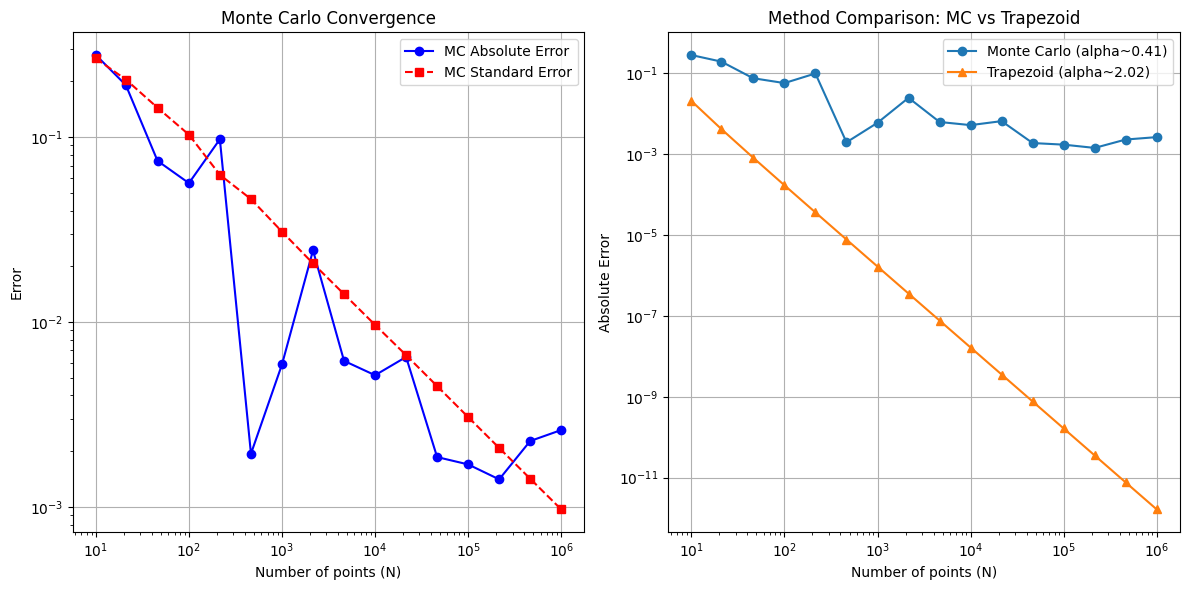

In [24]:
# Initial parameters
integral_ex = 2.0
lower, upper = 0, np.pi
N_vals = np.logspace(1, 6, num=16, dtype=int)

mc_abs_errors = []
mc_std_errors = []
tr_abs_errors = []

for N in N_vals:
    # MONTE CARLO
    integral_mc, std_err_mc = MC_1dim(lower, upper, func, N)

    mc_abs_errors.append(abs(integral_mc - integral_ex))
    mc_std_errors.append(std_err_mc)
    
    # TRAPEZOID
    x_trap = np.linspace(lower, upper, N)
    y_trap = np.sin(x_trap)

    integral_tr = np.trapezoid(y_trap, x_trap)
    
    tr_abs_errors.append(abs(integral_tr - integral_ex))

# List conversion to numpy so computer doesn't explode
N_vals = np.array(N_vals)
mc_abs_errors = np.array(mc_abs_errors)
mc_std_errors = np.array(mc_std_errors)
tr_abs_errors = np.array(tr_abs_errors)

# Calculate alpha for both methods
alpha_mc = calculate_alpha(N_vals, mc_abs_errors)
alpha_trap = calculate_alpha(N_vals, tr_abs_errors)

print(f'Monte Carlo alpha: {alpha_mc:.2f}, expected ~0.5')
print(f'Trapezoid alpha  : {alpha_trap:.2f}, expected ~2.0')


# Plots
plt.figure(figsize=(12, 6))

# Monte Carlo convergence and errors
plt.subplot(1, 2, 1)
plt.loglog(N_vals, mc_abs_errors, 'o-', color='blue', label='MC Absolute Error')
plt.loglog(N_vals, mc_std_errors, 's--', color='red', label='MC Standard Error')
plt.title('Monte Carlo Convergence')
plt.xlabel('Number of points (N)')
plt.ylabel('Error')
plt.grid()
plt.legend()

# Monte Carlo vs Trapezoid
plt.subplot(1, 2, 2)
plt.loglog(N_vals, mc_abs_errors, 'o-', label=f'Monte Carlo (alpha~{alpha_mc:.2f})')
plt.loglog(N_vals, tr_abs_errors, '^-', label=f'Trapezoid (alpha~{alpha_trap:.2f})')
plt.title('Method Comparison: MC vs Trapezoid')
plt.xlabel('Number of points (N)')
plt.ylabel('Absolute Error')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

How do this errors behave as the number of points increases?
- Both errors decreases in linear rate. Absolute error fluctuates but stays in proximity of standard error. 

Which method converges faster for this one-dimensional integral?
- Trapezoid method converges about 4x the speed of MC. The real advantage of MC is visible when calculationg multi-dimensional integrals.

How do these method errors scale as O($1/N^{\alpha}$)?
- Monte Carlo: O($1/N^{0.5}$)
- Trapezoid  : O($1/N^{2}$)

# Exercise 4: Higher dimension integration
In n-dimension

Simple Integration:
$$I = \int_{a}^{b}\int_{a}^{b} ...\int_{a}^{b}dx_1dx_2...dx_n f(x_1,x_2,...,x_n)$$
The estimation value:
$$\bar{I} = (b-a)^n \sum_{i=0}^{N-1} \dfrac{f(x_{1i},x_{2i},...,x_{ni})}{N}.$$
**Standard error** of the estimate:
 $$ \sigma_{\bar{I}} =    \dfrac{(b-a)^n}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (f(x_{1i},x_{2i},...,x_{ni}) - \overline{f})^2}$$

+	Define a function named **MC_ndim(lower,upper,func,n_dims,n_points)** to compute the integral of an arbitrary n-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and the standard error $\sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi}\int_{0}^{\pi} sin(x_1) sin(x_2) dx_1 dx_2$ 

+ Compute the above integral for $n_{dims} = 5,7,9$ and plot the absolute values $|\bar{I} - 2^n|$ for these dimension values as a function of n_points using log-log scale. Does the slope of error line change when we increase the dimension ? What is your conclusion ? 

In [ ]:
def func_ndim(x_vec):
    result = 1.0

    for x in x_vec:
        result *= math.sin(x)

    return result

def MC_ndim(lower, upper, func, dims, points):
    if points <= 1:
        raise ValueError("Number of points must be greater than 1.")
    if dims <= 0:
        raise ValueError("Number of dimensions must be greater than 0.")

    count = 0
    mean_f = 0.0
    M2 = 0.0
    
    for _ in range(points):
        # Generate a vector of random points
        x = [random.uniform(lower, upper) for _ in range(dims)]
        val = func(x)

        count += 1
        delta_1 = val - mean_f
        mean_f += delta_1 / count
        delta_2 = val - mean_f
        M2 += delta_1 * delta_2
    
    integral_f = (upper - lower)**dims * mean_f
    variance_f = M2 / (points - 1)
    std_dev_f = math.sqrt(variance_f)
    std_error_f = (upper - lower)**dims * std_dev_f / math.sqrt(points)

    return integral_f, std_error_f


integral_2d, std_err_2d = MC_ndim(0, math.pi, func_ndim, 2, 1_000_000)

print(f'Estimated 2D Integral: {integral_2d:.4f} (Expected: 4.0000)')
print(f'Standard Error: {std_err_2d:.4f}')
print(f'Absolute Error: {abs(integral_2d - 4.0):.4f}\n')

2D Integral estimate: 3.9978 (Expected: 4.0000)
Standard Error: 0.0029
Absolute Error: 0.0022



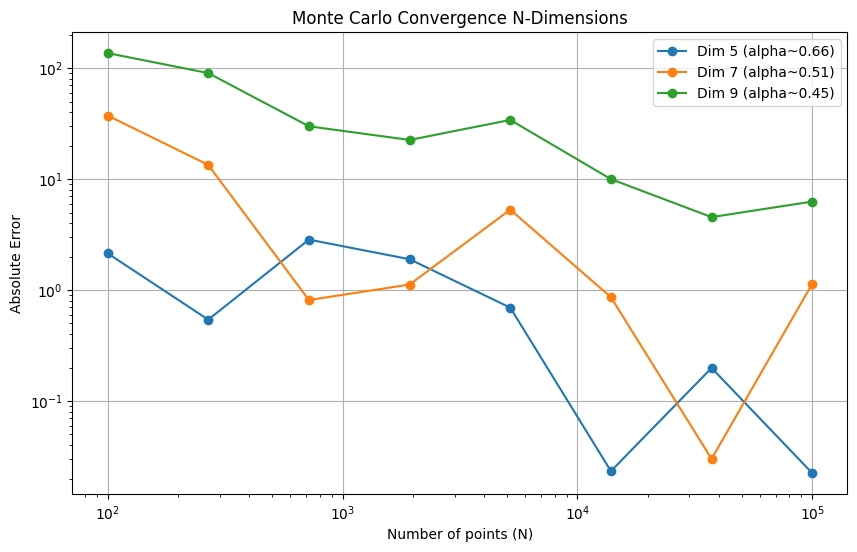

In [52]:
dims_list = [5, 7, 9]
N_vals = np.logspace(2, 5, num=8, dtype=int)

plt.figure(figsize=(10, 6))

for d in dims_list:
    abs_errors = []
    expected_val = 2.0**d
    
    for n in N_vals:
        res, _ = MC_ndim(0, math.pi, func_ndim, d, n)
        abs_errors.append(abs(res - expected_val))
    
    # Calculate alpha
    alpha = calculate_alpha(N_vals, abs_errors)
    
    plt.loglog(N_vals, abs_errors, 'o-', label=f'Dim {d} (alpha~{alpha:.2f})')

plt.title('Monte Carlo Convergence N-Dimensions')
plt.xlabel('Number of points (N)')
plt.ylabel(f'Absolute Error')
plt.grid()
plt.legend()
plt.show()

Does the slope of error line change when we increase the dimension?
- Not really. It still remains close to 0.5 regardless of dimensionality.
- This is an advantage of Monte Carlo methods compared to other - that the error is decreasing in stable rate.